# Naive Bayes Algorithm Practical Implementation With Iris Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [3]:
X, y = load_iris(return_X_y=True)

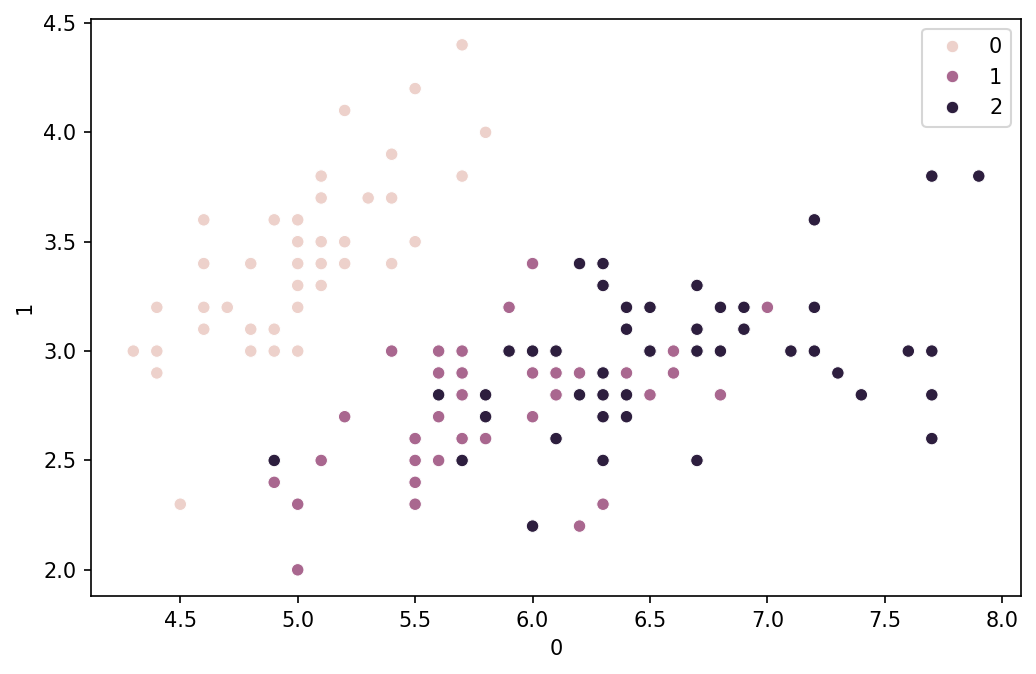

In [4]:
plt.figure(figsize=(8, 5), dpi=150)
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
pd.DataFrame(X_train).head()

,0,1,2,3
0,5.5,2.4,3.7,1.0
1,6.3,2.8,5.1,1.5
2,6.4,3.1,5.5,1.8
3,6.6,3.0,4.4,1.4
4,7.2,3.6,6.1,2.5


So here all the data contains the continuous values so we have to use the Gaussian Naive Bayes ML Model

In [7]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)


GaussianNB()

In [8]:
y_pred = gnb.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.9777777777777777
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


# Naive Bayes Algorithm Implementation on the Tips Dataset With Feature Engineering

In [10]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [11]:
df['smoker'] = np.where(df['smoker'].str.contains('No'), 0, 1) ## converting in binary
df['sex'] = np.where(df['sex'].str.contains('Female'), 0, 1) ## converting in binary

In [12]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,Sun,Dinner,2
1,10.34,1.66,1,0,Sun,Dinner,3
2,21.01,3.50,1,0,Sun,Dinner,3
3,23.68,3.31,1,0,Sun,Dinner,2
4,24.59,3.61,0,0,Sun,Dinner,4


In [13]:
## OneHotEncoding on the data
from sklearn.preprocessing import OneHotEncoder
encod_col = OneHotEncoder()
encode =encod_col.fit_transform(df[['day', 'time']]).toarray()

In [14]:
encode

array([[0., 0., 1., 0., 1., 0.],
       [0., 0., 1., 0., 1., 0.],
       [0., 0., 1., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1., 0.],
       [0., 0., 0., 1., 1., 0.]])

In [15]:
encode_values = pd.DataFrame(encode, columns=encod_col.get_feature_names_out())

In [16]:
df = pd.concat([df, encode_values], axis=1)
df.head()

,total_bill,tip,sex,smoker,day,time,size,day_Fri,day_Sat,day_Sun,day_Thur,time_Dinner,time_Lunch
0,16.99,1.01,0,0,Sun,Dinner,2,0.0,0.0,1.0,0.0,1.0,0.0
1,10.34,1.66,1,0,Sun,Dinner,3,0.0,0.0,1.0,0.0,1.0,0.0
2,21.01,3.50,1,0,Sun,Dinner,3,0.0,0.0,1.0,0.0,1.0,0.0
3,23.68,3.31,1,0,Sun,Dinner,2,0.0,0.0,1.0,0.0,1.0,0.0
4,24.59,3.61,0,0,Sun,Dinner,4,0.0,0.0,1.0,0.0,1.0,0.0


In [17]:
df.drop(['day', 'time'], axis=1, inplace=True)
df.head()

,total_bill,tip,sex,smoker,size,day_Fri,day_Sat,day_Sun,day_Thur,time_Dinner,time_Lunch
0,16.99,1.01,0,0,2,0.0,0.0,1.0,0.0,1.0,0.0
1,10.34,1.66,1,0,3,0.0,0.0,1.0,0.0,1.0,0.0
2,21.01,3.50,1,0,3,0.0,0.0,1.0,0.0,1.0,0.0
3,23.68,3.31,1,0,2,0.0,0.0,1.0,0.0,1.0,0.0
4,24.59,3.61,0,0,4,0.0,0.0,1.0,0.0,1.0,0.0


In [18]:
X = df.drop('smoker', axis=1)
y = df['smoker']

In [19]:
X.head()

,total_bill,tip,sex,size,day_Fri,day_Sat,day_Sun,day_Thur,time_Dinner,time_Lunch
0,16.99,1.01,0,2,0.0,0.0,1.0,0.0,1.0,0.0
1,10.34,1.66,1,3,0.0,0.0,1.0,0.0,1.0,0.0
2,21.01,3.50,1,3,0.0,0.0,1.0,0.0,1.0,0.0
3,23.68,3.31,1,2,0.0,0.0,1.0,0.0,1.0,0.0
4,24.59,3.61,0,4,0.0,0.0,1.0,0.0,1.0,0.0


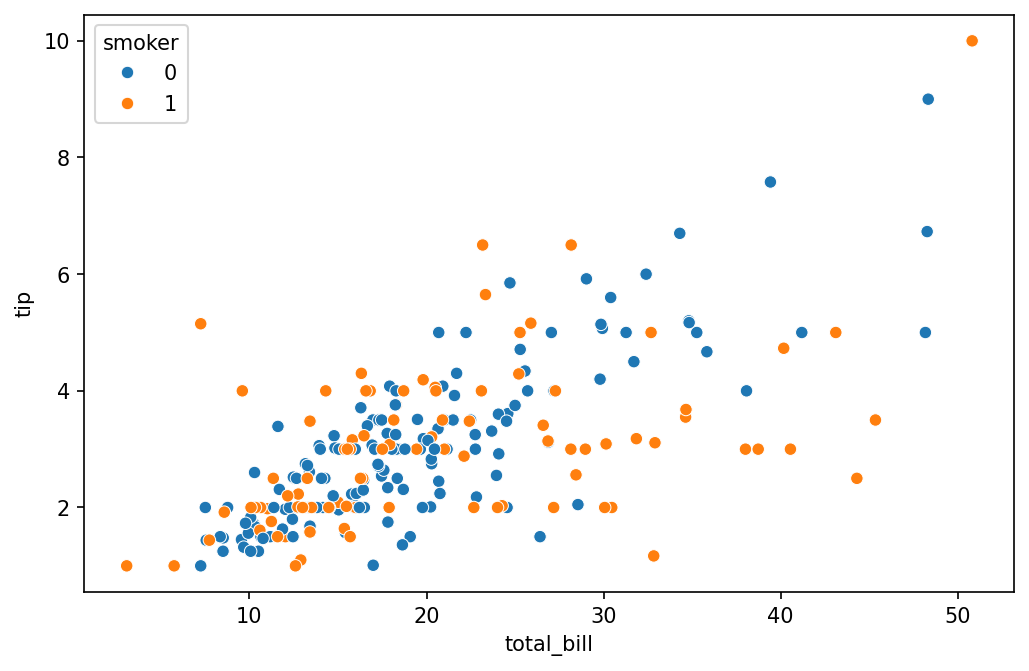

In [20]:
plt.figure(figsize=(8, 5), dpi=150)
sns.scatterplot(x=X['total_bill'], y=X['tip'], hue=y)
plt.show()

In [21]:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.25, random_state=42)

In [22]:
ngnb = GaussianNB()
ngnb.fit(X_train, y_train)


GaussianNB()

In [23]:
y_pred_new = ngnb.predict(X_test)

In [24]:
print(accuracy_score(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))
print(confusion_matrix(y_test, y_pred_new))

0.7049180327868853
              precision    recall  f1-score   support

           0       0.73      0.85      0.79        39
           1       0.62      0.45      0.53        22

    accuracy                           0.70        61
   macro avg       0.68      0.65      0.66        61
weighted avg       0.69      0.70      0.69        61

[[33  6]
 [12 10]]
